# Learning Objectives

After reading this notebook, students should be able to

+ Learn the basics about various RL Toolkits
+ Understand the usage of OpenAI Gym that can be used to analyze various RL algorithms
+ Learn about some environments that simulates real world environments





# Pre-requisites
+ Basic understanding of RL terminologies


# Reinforcement Learning
So far, you have studied various Reinforcement Learning concepts and put them into use in some simple problems like the Grid world. There you built your own Grid world environment with all the environment dynamics and reward functions. And then you built an agent that interacts with the environment. But wouldn't it be great if there were some standard environments out there and you only need to focus on the implementation of the algorithms. In this chapter, we will learn about such tools and the usage of the most popular tool. But first, recall some of the RL terminologies again from the first chapter of this module, that is, Introduction to Reinforcement Learning, as those terminologies are key to understand the working of the tools we will explain later.
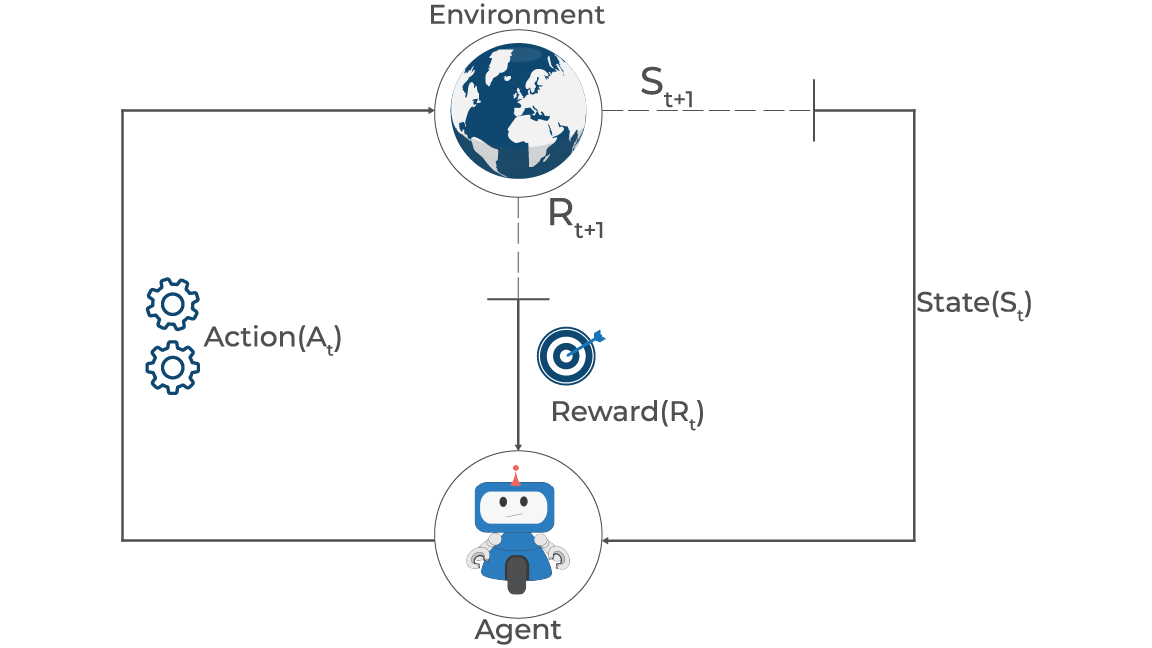
<figure>
<center>
</center>
</figure>
<center>
Figure 1: RL System
</center>

In an RL system, the agent, which is also known as a learner, interacts with the environment and receives feedback called reward from the environment. In RL, the timesteps are considered to be discrete. And at the first time step($t_0$), the agent observes the current state of the environment($S_0$) and the agent applies an action($A_0$) that seems suitable for that state to the environment through its available actuators. And subsequently, the applied action changes the state of the environment to $S_1$ and a reward $R_1$ is returned from the environment to appraise the action taken $A_1$. This cycle continues at the following timesteps, generating a sequence of states, actions, and rewards. And the main goal here is to learn an optimal policy so that the agent selects an appropriate action for each state so as to maximize the cumulative reward after multiple iterations.
$$
S_0, A_0, R_1, S_1, A_1, R_2, \dots\dots\dots
$$
 
Now since we have recalled some important RL terminologies let's dive into the RL toolkit, what it is and why is it important.



# RL Toolkit
As we learned before, Reinforcement Learning is an area of Machine Learning where the agent learns to take action in an environment so as to maximize the cumulative reward. And the environment in which an agent works is something that simulates various systems. And the system can be as simple as a Gridworld problem to as complex as a self-driving car. We can have other systems also as RL environment if they can be modeled as a Markov Decision Process. Various researchers develop their own environment following the dynamics of the system they tend to model. And other researchers or learners usually recreate the environment on their own and use the environment to work out their various Reinforcement Learning Algorithms.
And various RL toolkits available today is basically a collection of such environments and also provides interfaces to build our own environments. Such toolkits allow us to focus on developing and comparing reinforcement learning algorithms instead of wasting time on recreating or building environments on our own. These toolkits are generic and make no assumption about the agent and the algorithm used by the agent. Let's explore the need for RL toolkits in Reinforcement Learning in the following points.
1. **Better benchmarking:**<br>
  Reinforcement Learning is almost as old as Supervised or Unsupervised Learning. Today we can see that there has been much advancement in supervised and unsupervised learning but the advancement in RL is quite behind the other two categories of ML. And one of the major reasons behind it is the lack of better benchmarking. If we look into supervised learning, [Imagenet project](https://en.wikipedia.org/wiki/ImageNet) alone was responsible for some of the major advancements in computer vision. So, RL Toolkits provides a collection of popular environments in a single place with easier interfaces that allows benchmarking and developing various reinforcement learning algorithms and are easy to setup.
2. **Standardization problem in publications:**<br>
  As we discussed earlier, the environments are introduced by researchers in their publications, and things may not be always clearly defined. And small differences in the problem definition may make the creation of the environment difficult or may not create the same environment as proposed by the original researcher. And this issue makes it difficult to reproduce published research and compare the results of various RL algorithms. So, a standard toolkit provides a common standard set of environments in which various researchers can work on and expect similar results from similar algorithms with a similar setup.
  
Now, since we have discussed the need for RL toolkits, let's explore some popular RL toolkits. OpenAI Gym and Unity ML-Agents are some of the most popular toolkits. In this chapter, we will explore the OpenAI Gym in detail and only briefly explore Unity ML-Agents.


# OpenAI Gym
<center>
<figure>
<p>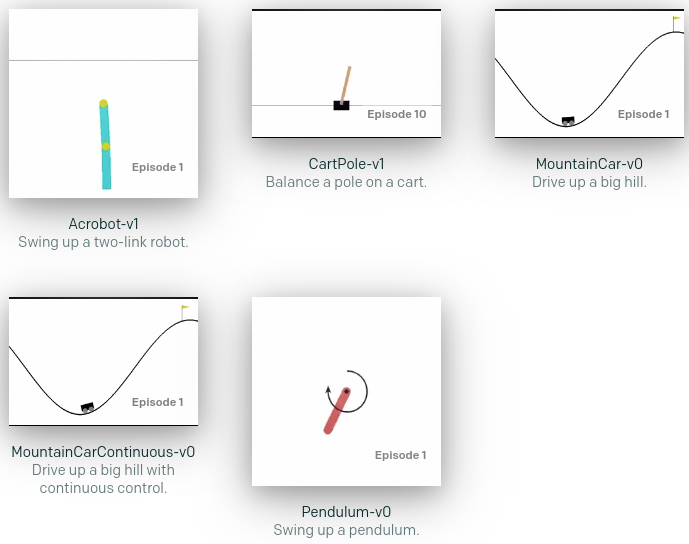</p>
<figcaption align='center'> Figure 1: OpenAI Gym Classic Control Environments(src:<a href="https://gym.openai.com/envs/#classic_control">OpenAI Gym</a>)</figcaption>
</figure>
</center>

The gym is an RL toolkit developed by OpenAI which provides a collection of environments for RL experiments using a unified interface. And this collection of environments can be used to develop and compare various RL algorithms. Gym provides wide varieties of environments ranging from simple toy games like Blackjack to complex games like <a href="https://gym.openai.com/envs/#atari">Atari</a> and even <a href="https://gym.openai.com/envs/#robotics">Robotics</a>. OpenAI Gym allows users to build an agent that interacts with the environment and learns to perform various planned tasks in the environment.



## Environment
An OpenAI gym provides an `Env` class, which represents the environment, is the core gym interface. And the agent interface that interacts with the environment is something that the user needs to build. Now let's explore the two main components of the environment
1. **Action space:**<br>
   Action space consists of a set of actions that an agent can execute in the environment. And the actions can be discrete, continuous, or a combination of both. Discrete actions are a fixed set of actions that an agent can do. For example in the case of Grid world, the possible actions are up, left, bottom, and right. A continuous action takes a real-valued number, for example, in the case of a robotic arm, the action value could be 0$^\circ$ to 360$^\circ$ rotation of a joint. And some environment supports both types of actions.
2. **Observation space:**<br>
  Observation is the information provided by the environment to the agent at each timestep beside the reward. Observations can be from as simple as a single variable with two possible values to as complex as several multidimensional arrays with values ranging in a very wide range. An observation can be discrete, for example, a switch that can be on or off, and an observation can also be continuous, for example, a position of a car in a city map.

OpenAI Gym supports 6 different types of spaces in total currently. And they are:
1. **Discrete:**<br>
    Discrete space consists of a mutually exclusive set of items of size `n`, numbered from `0` to `n-1`. It's only field is `n`, which is the count of the items and is stated as
    ```python
    gym.spaces.Discrete(n)
    ```
    For example in case of gridworld, we will have action space, Discrete(4), which means there are two distinct possible actions: up, down, left and right.

2. **Box:**<br>
    Box space represents an n-dimensional tensor of rational numbers with bounds(upper bound and lower bound). 
    ```python
    # Identical bound for each dimension
    gym.spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
    ```
    It defines a 2 dimensional space and both dimensions value ranges from -1.0 to +1.0.
    ```python
    # Independent bound for each dimension
    gym.spaces.Box(low=np.array([-2.0,-3.0]), high=np.array([1.0,2.0]), dtype=np.float32)
    ```
    It also defines a 2 dimensional space, where the first dimension value can range from -2.0 to +1.0 and the second dimension value can range from -3.0 to +2.0.

3. **Tuple:**<br>
    Tuple space allows to combine several other Space class instances together. This allows to create spaces of complexities according to our need. 
    ```python
    gym.spaces.Tuple(spaces=(gym.spaces.Discrete(2), gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)))
    ```
    Here the tuple space has allowed us to define a space which is the combination of both discrete and box space.
5. **Dict:**<br>
   Somewhat like Tuple, Dict allows to define a dictionary of simple space types.
   ```python
   gym.spaces.Dict({"time":gym.spaces.Discrete(60), "space":gym.spaces.Box(low=-1.0,high=1.0,shape=(3,), dtype=np.float32)})
   ```
   A dictionary space with Discrete space for time and Box space for space.
4. **Multi Discrete:**<br>
    It is a multi-dimensional discrete space, which consists of series of `Discrete` spaces with different number of choices in each
    ```python
    gym.spaces.MultiDiscrete([2,4,6])
    ```
    This defines 3 discrete spaces with 2, 4 and 6 possible values each.
6. **Multi Binary :**<br>
    This space defines n-dimensional binary space.
    ```python
    gym.spaces.MultiBinary(n)
    ```
    This defines a `n` dimensional binary space.
 
### Functionalities of an Environment
Now let's explore three major functionalities provided by Gym environment at a high level.
1. **step():**<br>
  The gym uses the `step()` method to allow the agent to take an action in the environment. And after the application of the action, the function returns four values. The values are:
  + observation:<br>
     A numpy matrix representing the new observation of the environment after the application of the action.
  + reward:<br>
     It is the amount of reward received after applying the action
  + done:<br>
     A boolean indicator indicating whether the episode is over or not.
  + info:<br>
     This could be anything environment-specific with extra information about the environment.
2. **reset():**<br>
   This method resets the environment to its initial state and returns the initial state vector
3. **render():**<br>
   This method returns the state of the environment in a human-friendly form mainly for visualization.


## OpenAI Demo
To understand the working of OpenAI Gym, we will demonstrate a Gym environment called `MountainCar-v0`
### Installation
You can install `gym` easily using `pip` with python version greater than 3.5.
```python
pip install gym
```


### Pendulum-v0 Environment
<center>
<figure>
<p>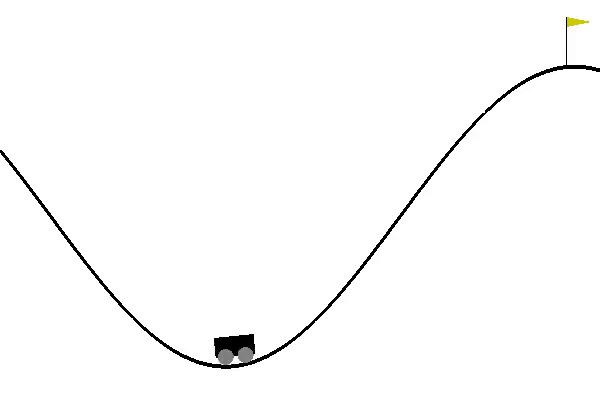</p>
<figcaption align='center'> Figure 2: MountainCar-v0</figcaption>
</figure>
</center>

The `MountainCar-v0` environment consists of a car in between two mountains as shown in the figure 2. The goal is to drive the car up the mountain on the right to the yellow flag by using the momentum generated by driving the car back and forth. Now considering this environment, let's explore various functionalities of Gym in following steps


#### 1. Import Libraries
```python
import gym
```
 
#### 2. Instantiate the environment
```python
env = gym.make('MountainCar-v0')
```
#### 3. Action space
We can get the information about action space with the following command
```python
env.action_space
```
Output
```
Discrete(3)
```
The output `Discrete(3)` signifies an action size of 1 which can take value from a set of 3 possible actions.
 
#### 4. Observation space
We can use the following command for observation space information
```python
env.observation_space
```
Output
```
Box(-1.2000000476837158, 0.6000000238418579, (2,), float32)
```
The output `Box(-1.2000000476837158, 0.6000000238418579, (2,), float32)` signifies a state size of 2, continous action space and the first variable ranges from -1.2 to 0.6.
 
Further details about the environment can be found [here](https://github.com/openai/gym/wiki/MountainCar-v0).



#### 5. Intial observation
Now let's get the state of the environment at timestep 0.
```python
state = env.reset()
state
```
Output
```python
array([-0.42784806,  0.        ])
```
 
#### 6. Demo
Now let's see a demo of Gym.
```python
total_reward = 0
env.reset()
while True:
   # selects a random action
   action = env.action_space.sample()
   env.render()
   next_state, reward, done, info = env.step(action)
   total_reward += reward
   if done:
       print("Total reward: {}".format(total_reward))
       break
```
Output
```python
Total reward: -200.0
```
<center>
<figure>
<p>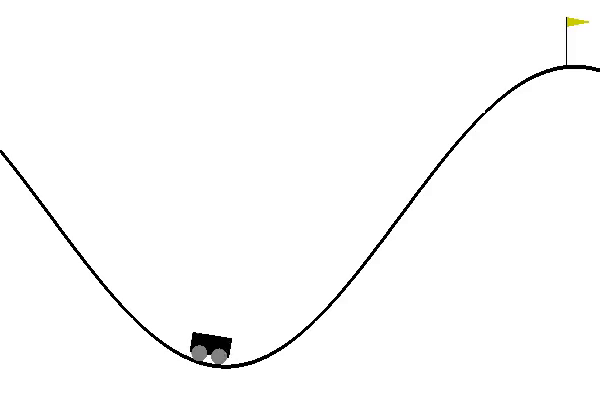</p>
<figcaption align='center'> Figure 3: Demo output</figcaption>
</figure>
</center>
 
So this is a simplistic demo of working of OpenAI Gym and it is up to the user to later work on to develop an agent that interacts with the environment and learns an optimal policy.



# Unity ML-Agents Toolkit
<center>
<figure>
<p>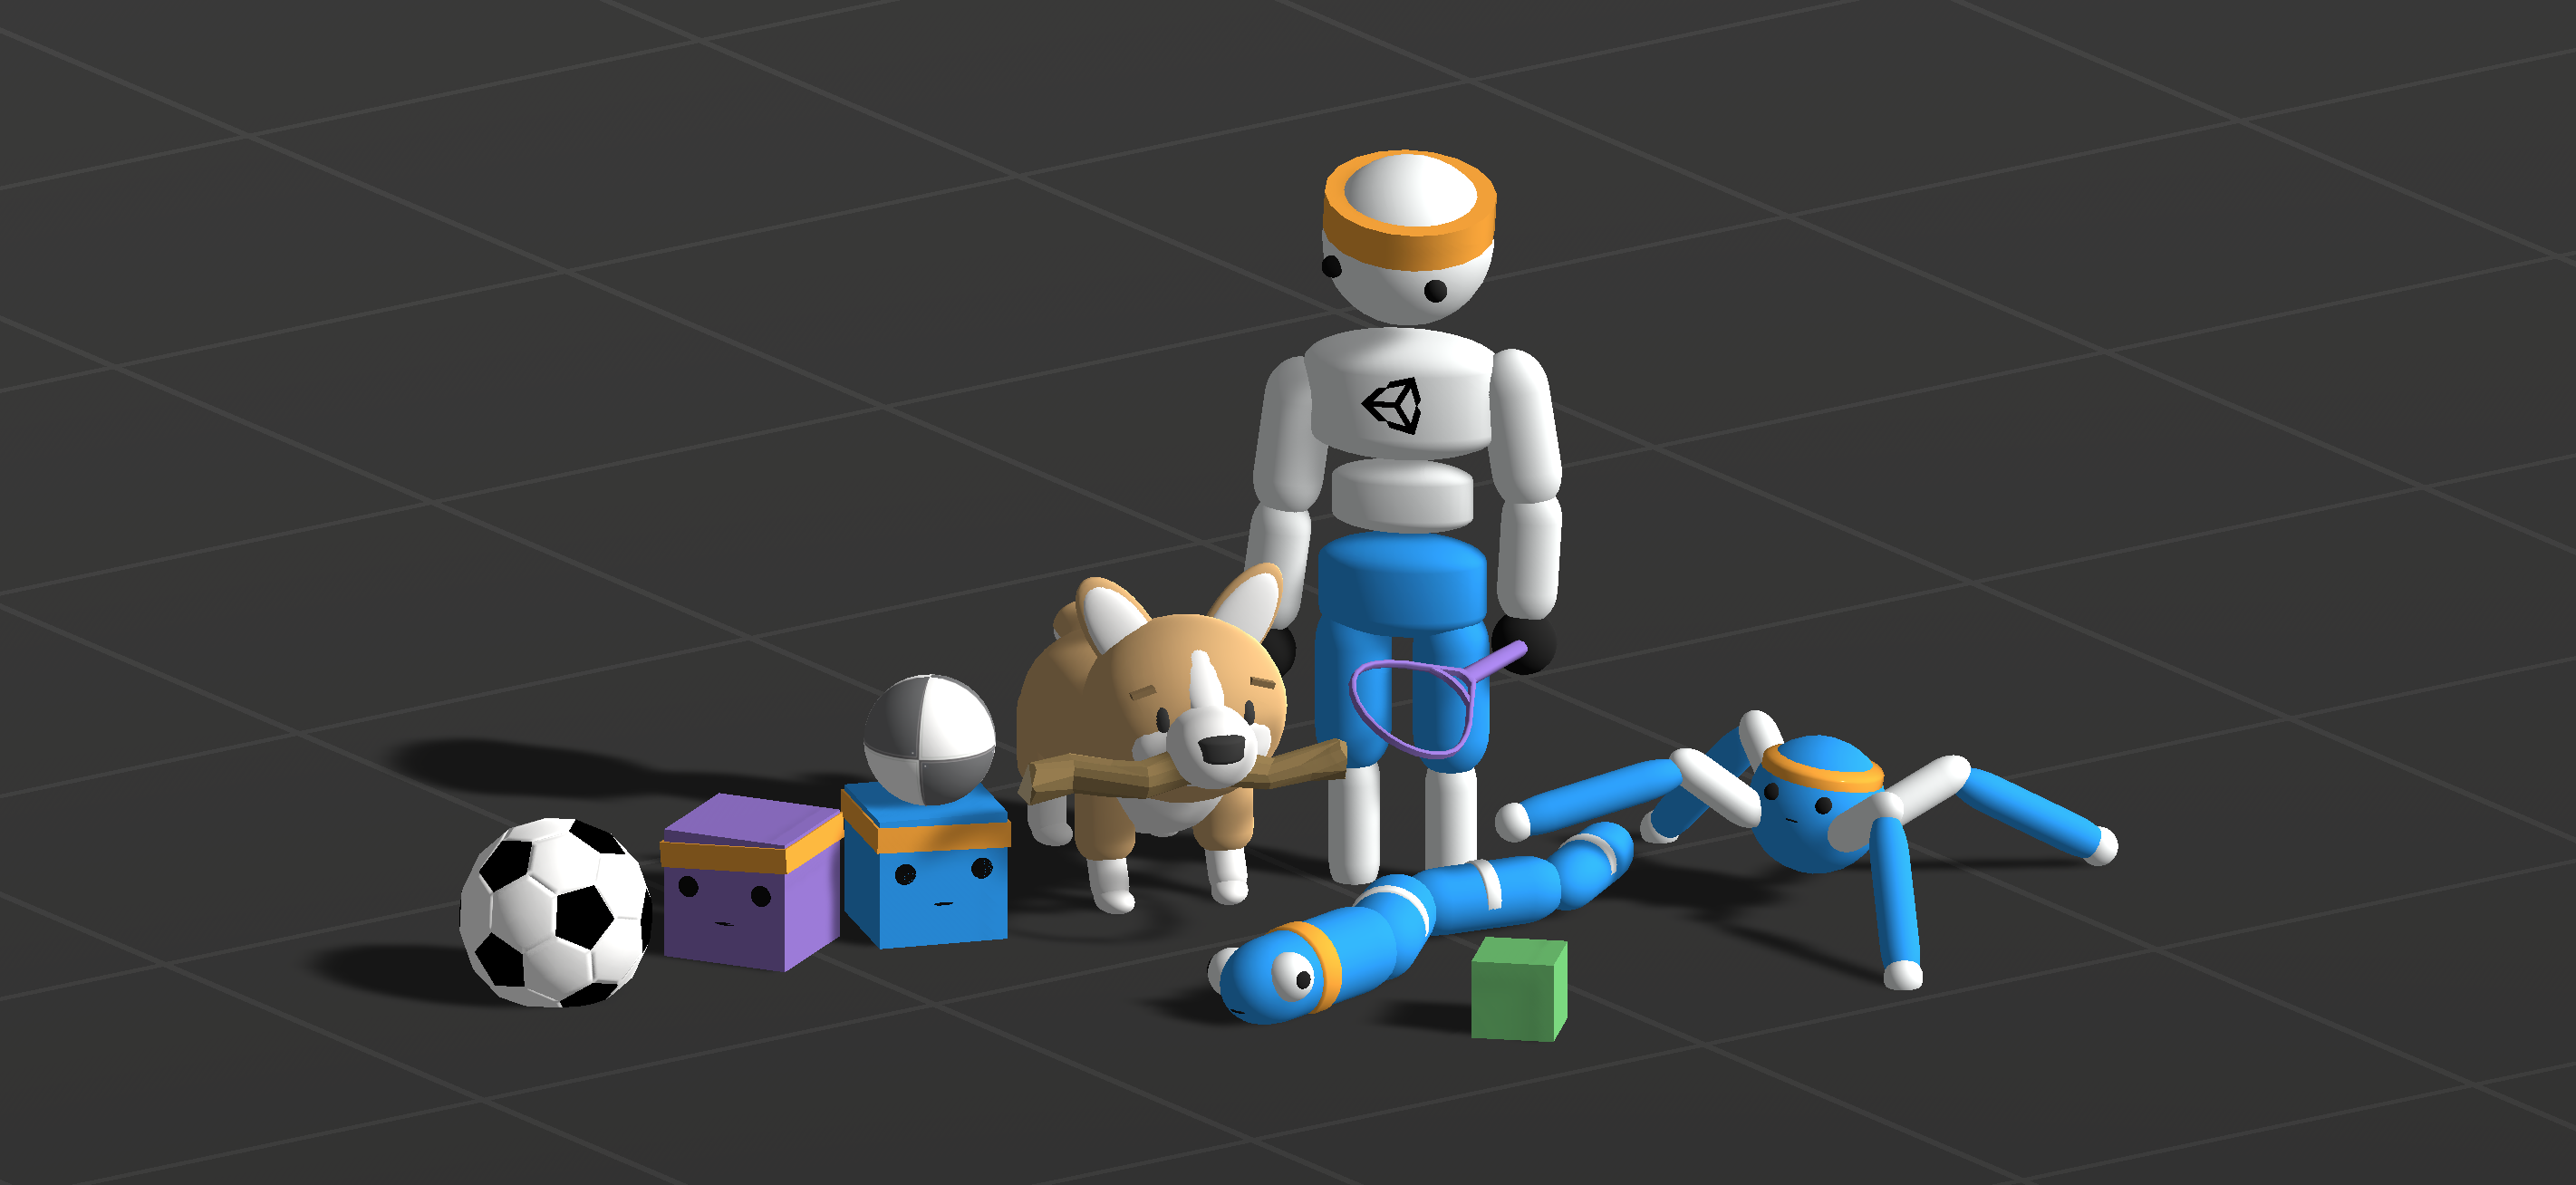</p>
<figcaption align='center'> Figure 4: Unity ML-Agents Toolkit(src:<a href="https://github.com/Unity-Technologies/ml-agents/blob/master/docs/images/image-banner.png">ml-agents</a>)</figcaption>
</figure>
</center>

Unity Machine Learning Agents(ML-Agents) is an open-source Unity plugin that allows Unity games and simulations to use as environments for training various agents using various algorithms through a simple-to-use Python API. We will be using OpenAI Gym environments for the rest of our course and it is the most widely used toolkit so we will go through ML-Agents at a high level only.
 
The Unity ML-Agents toolkits provide some core functionalities which allow users to create an environment using the Unity Editor and associated C# scripts which can then expose the environments for interaction using the Python API.



## Environment
<center>
<figure>
<p>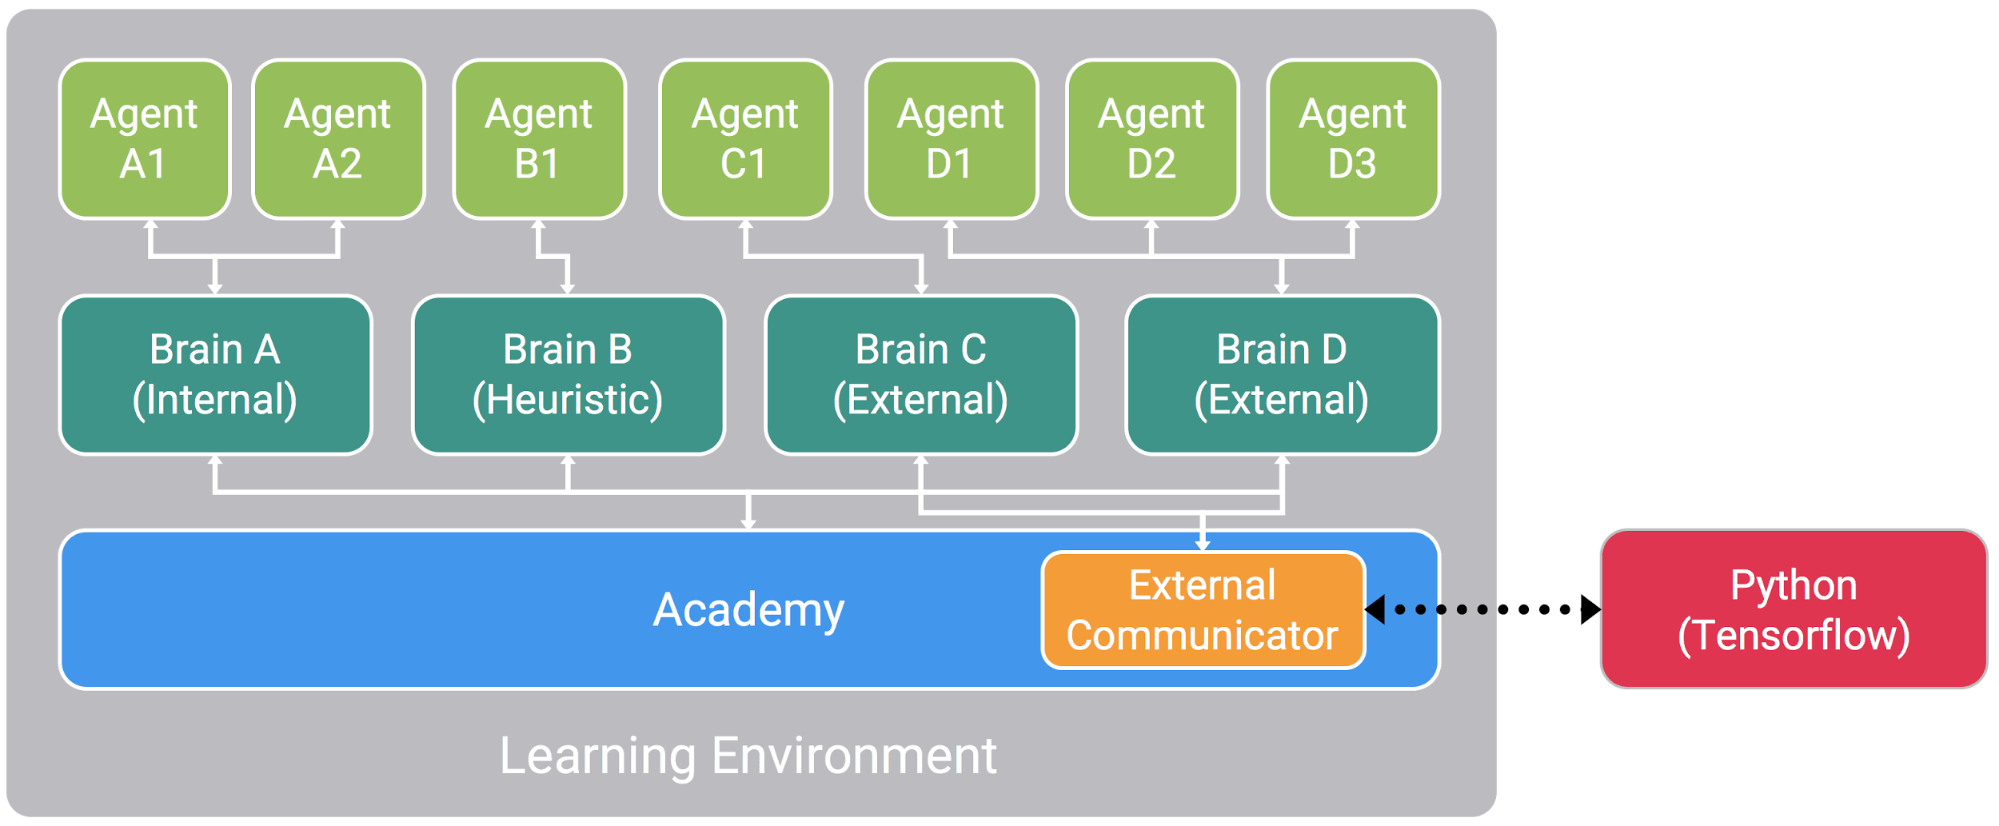</p>
<figcaption align='center'> Figure 5: A Learning Environment(src:<a href="https://blogs.unity3d.com/wp-content/uploads/2017/09/image4.png">Introducing: Unity Machine Learning Agents Toolkit</a>)</figcaption>
</figure>
</center>


A Unity ML-Agents Learning Environment consists of three types of objects. And they are:<br>
1. **Agent:**<br>
   The agent is the agent that we have been learning. It performs an action within the environment and collects necessary observations from the environment. In ML-Agents, the agent's action is decided by the brain it’s connected to.
2. **Brain:**<br>
  Like the human brain, the brain here makes all the decisions for the agent. In the figure, we can see that each agent is connected to a brain showing that multiple agents can share a common brain but a single agent cannot have multiple brains. And the brain can be set to one of the four modes.
  + Player: Action decisions are made through the player's input
  + Heuristic: Action decisions are made through predefined scripts
  + Internal: Action decisions are made through internally embedded neural networks
  + External: Action decisions are made via Python API
3. **Academy:**<br>
   Each learning environment contains one academy. Some of the major tasks of the academy are to oversee the unity engine's configuration, keep track of steps of the simulation process, etc.
 
The states and observations of all agents with brains set to External are collected by the External Communicator and communicated to our Python API for processing.



## Unity ML-Agents Demo
To understand the working of Unity ML-Agents, we will demonstrate a popular unity environment called `Reacher`
### Installation
You can install `Unity ML-Agents` easily using `pip`.
```bash
pip install mlagents
pip install unityagents
```



### Reacher Environment
<center>
<figure>
<p>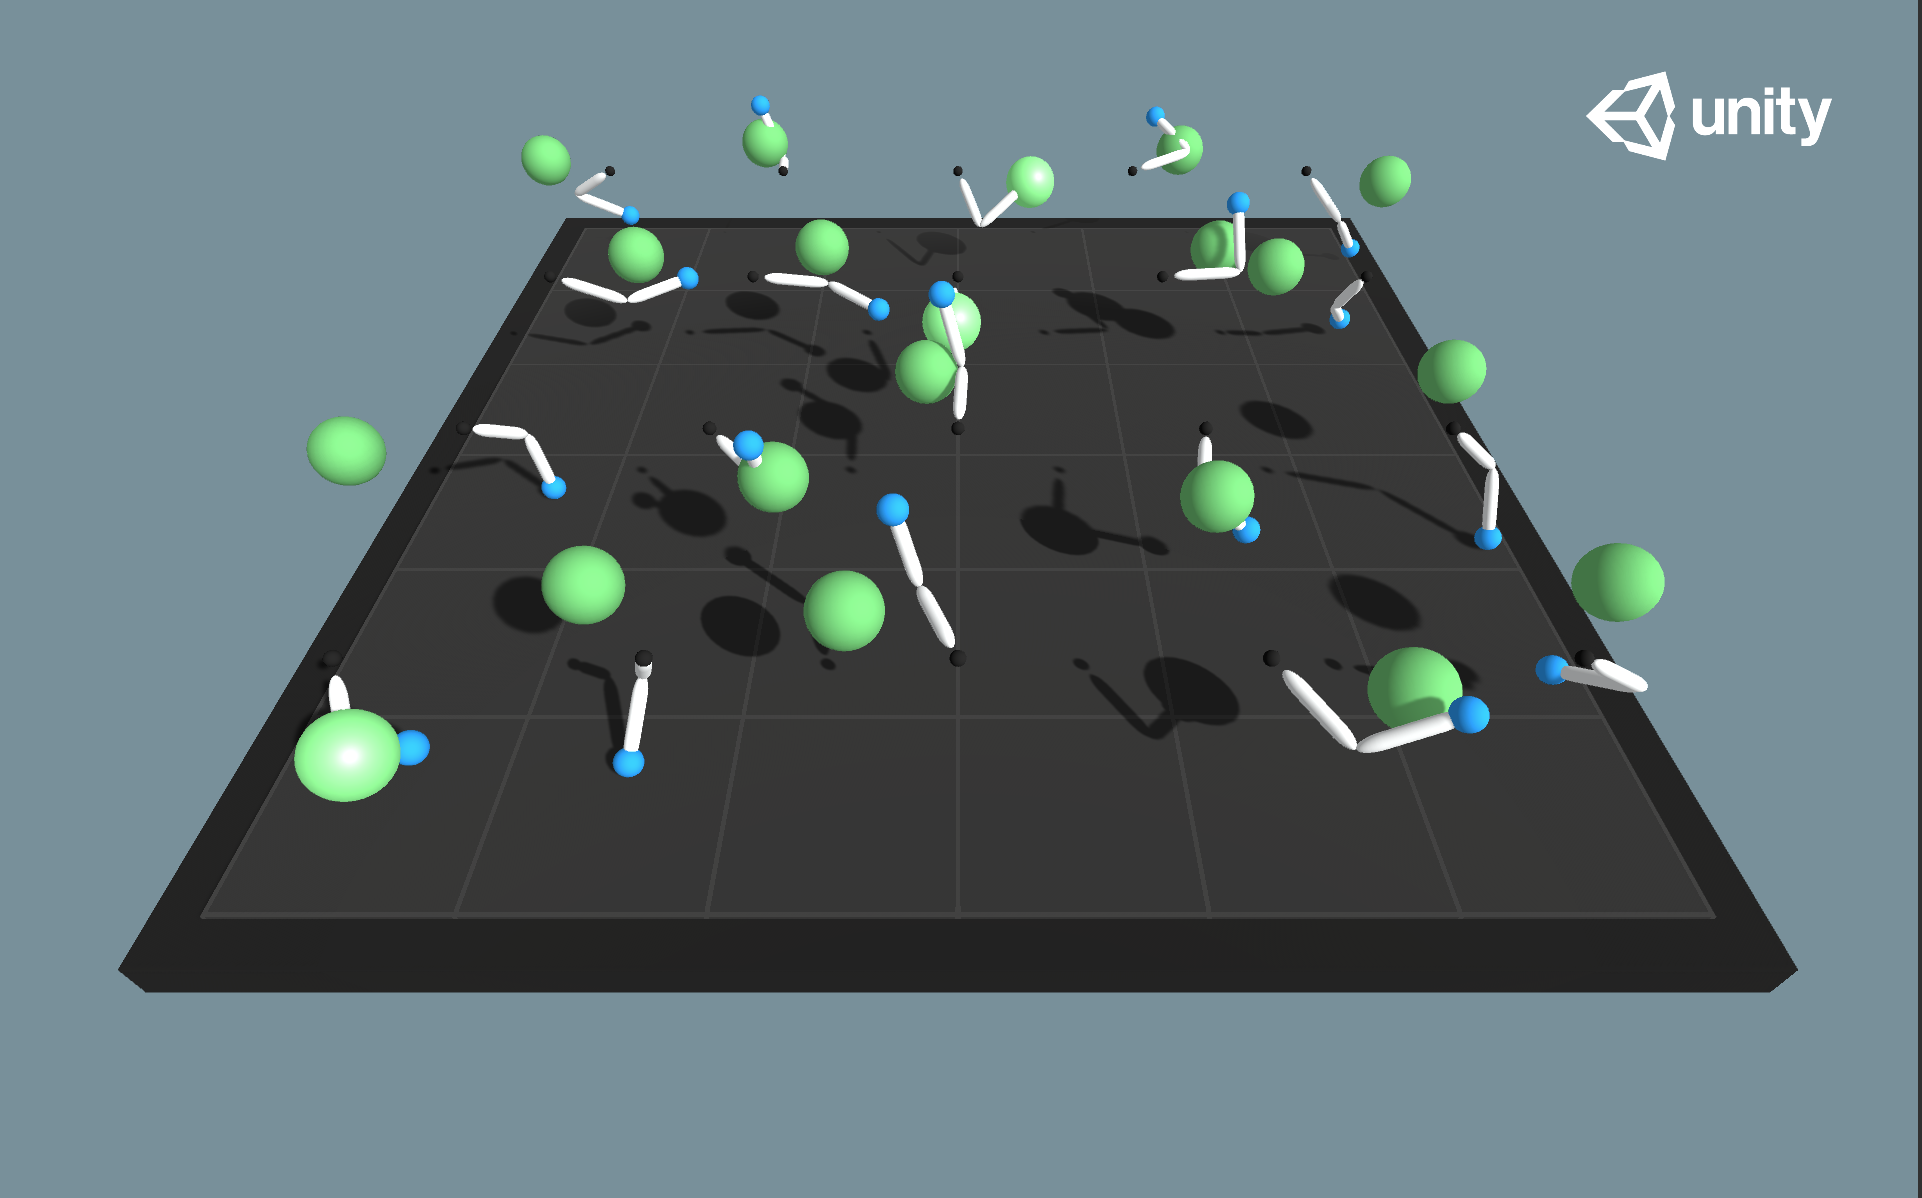</p>
<figcaption align='center'> Figure : Reacher(src:<a href="https://github.com/Unity-Technologies/ml-agents/blob/master/docs/images/reacher.png">Unity Technologies</a>)</figcaption>
</figure>
</center>




The `Reacher` environment consists of a 20 double-jointed arm and 20 different targets represented by the green ball. The goal is to move the agent’s hand(blue ball) to the goal location and keep that there. Now considering this environment, let's explore various functionalities of Unity ML Agent in the following steps


#### 1. Import Libraries
```python
import numpy as np
from unityagents import UnityEnvironment
```
 
#### 2. Instantiate the environment
```python
env = UnityEnvironment(file_name="Reacher.x86_64")
```
 
#### 2. Get the brain
```python
brain_name = env.brain_names[0]
```
Output
```python
'ReacherBrain'
```
```python
brain = env.brains[brain_name]
```
 
#### 3. Environment Informations
We can use `reset()` to get the initial environment information. Let's explore some properties
```python
env_info = env.reset(train_mode=True)[brain_name]
 
num_agents = len(env_info.agents)
print('No. of agents:', num_agents)
 
# Action space
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)
 
# state space
states = env_info.vector_observations
state_size = states.shape[1]
print('State size of each agent: {}'.format(state_size))
```
Output
```
No. of agents:20
Size of each action:4
State size of each agent: 33
```


#### 4. Reacher working
```python
# Reset the environment with False train mode
env_info = env.reset(train_mode=False)[brain_name]
states = env_info.vector_observations 
scores = np.zeros(num_agents)
while True:
    # select an action
    actions = np.random.randn(num_agents, action_size)
    env_info = env.step(actions)[brain_name]
    next_states = env_info.vector_observations
    rewards = env_info.rewards 
    dones = env_info.local_done
    scores += env_info.rewards    
    if np.any(dones):
        print('Average score: {}'.format(np.mean(scores)))
        break
env.close()
```
Output
```python
Average score: 0.07499999832361937
```


So this is a simple tutorial of Unity ML-Agents using the Reacher environment. Other environments including Rechear can be found [here](https://github.com/Unity-Technologies/ml-agents/tree/master/Project/Assets/ML-Agents/Examples). And also you won't be able to find the environments in an executable format like `.exe`, `.app` or `x86`. For that, you can follow this [tutorial](https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Learning-Environment-Executable.md) to convert the environments into an executable format.


# Real World Environments
So far we have discussed various environments but they are either toy examples or only game-related. But is RL applicable to the Gaming environment only?? Definitely not. Now let's explore some environments which are related to real-world application.
1. **CARLA:**<br>
   CARLA is an open-source autonomous driving simulator. CARLA is a toolkit for the development, training, and validation of autonomous driving systems. CARLA consists of two main modules and they are:
   + CARLA simulator:<br>
       The simulator is responsible for controlling the logic, mechanics, and rendering of all actors and sensors in the simulation environment.
   + CARLA Python API:<br>
       The Python API provides an interface for controlling the simulator and retrieving information about the simulation environment.
2. **Trading environments:**<br>
   Various trading environments can be modeled as Reinforcement Learning environments. Foreign Exchange Market(FOREX) and Stock trading are two of the most widely modeled trading environments. For any trading environment, we need to define trading actions and trading positions. Some of the popular trading actions are BUY, SELL, HOLD, ENTER, EXIT, etc. And trading [position](https://en.wikipedia.org/wiki/Position_(finance)) is the amount of security, commodity, or currency held or owned by an individual or financial entity. You can study the actions and positions and build your own environment or you can use some of the already built environments. Some of the most popular stock trading environments are [Gym Anytrading](https://github.com/AminHP/gym-anytrading), [Sairen](https://gitlab.com/doctorj/sairen/), [Trading Gym](https://github.com/6-Billionaires/trading-gym), etc.



# Takeaways
+ OpenAI Gym and Unity ML-Agents can be can be used to test various experiments
+ We can also create our own custom environments in Gym and ML-Agents
+ RL can also be used to model other real world systems


# References
* Articles
   * Juliani Arthur (2017), Introducing: Unity Machine Learning Agents Toolkit, https://blogs.unity3d.com/2017/09/19/introducing-unity-machine-learning-agents/?_ga=2.266518663.826941952.1608207175-1188719444.1608207175
  
   * ML Agents, Using an Environment Executable
, https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Learning-Environment-Executable.md


